In [5]:
import xarray as xr        # Import xarray for working with multi-dimensional labeled datasets, useful for climate, weather, and oceanographic data
import pandas as pd         # Import pandas for data manipulation and analysis
import numpy as np          # Import numpy for numerical operations on arrays and matrices
import matplotlib.pyplot as plt  # Import matplotlib for creating static, animated, and interactive visualizations

## Data Understanding & Exploration

#### 1950

 File found: C:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\raw\tunisia_2m_temperature_1950.nc
📂 Dataset structure:
<xarray.Dataset> Size: 20MB
Dimensions:     (valid_time: 8760, latitude: 31, longitude: 18)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 1950-01-01 ... 1950-12-31T23...
  * latitude    (latitude) float64 248B 37.73 37.48 37.23 ... 30.73 30.48 30.23
  * longitude   (longitude) float64 144B 7.52 7.77 8.02 ... 11.27 11.52 11.77
    expver      (valid_time) <U4 140kB ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 20MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-14T08:55 GRIB to CDM+CF via cfgrib-0.9.1...

🌡 Variable Info (2m Tempe

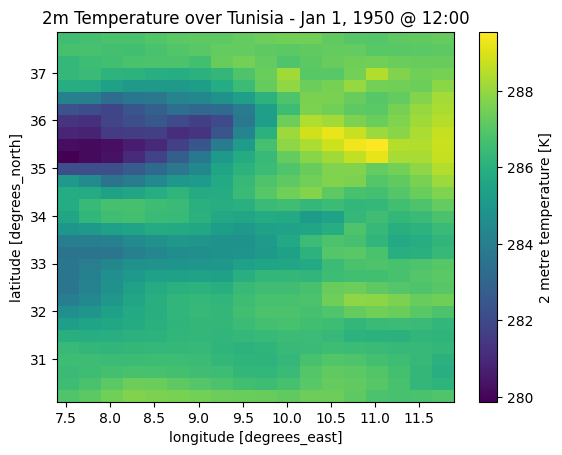


 Basic Statistics (in Kelvin):
Mean: 286.0693664550781
Min: 279.872314453125
Max: 289.536376953125


In [6]:

import os

#  Set the path to the file (1950)
file_path = r"C:\Users\yosrc\OneDrive\Desktop\1950-2025 temp\data\raw\tunisia_2m_temperature_1950.nc"

#  Check if the file exists before loading
if not os.path.exists(file_path):
    raise FileNotFoundError(f"❌ File not found: {file_path}")
else:
    print(f" File found: {file_path}")

#  Load the dataset
ds = xr.open_dataset(file_path)

# 📂 Show dataset structure
print("📂 Dataset structure:")
print(ds)

#  Check variable info
print("\n🌡 Variable Info (2m Temperature):")
print(ds['t2m'])

#  Plot a single day's temperature data using valid_time
sample_day = ds['t2m'].sel(valid_time='1950-01-01T12:00:00')
sample_day.plot()
plt.title("2m Temperature over Tunisia - Jan 1, 1950 @ 12:00")
plt.show()

#  Get basic statistics (in Kelvin)
print("\n Basic Statistics (in Kelvin):")
print("Mean:", sample_day.mean().values)
print("Min:", sample_day.min().values)
print("Max:", sample_day.max().values)


📊 Winter Day (1950-01-01 @ 12:00) Statistics:
Mean: 12.919209480285645
Min: 6.722320556640625
Max: 16.386383056640625


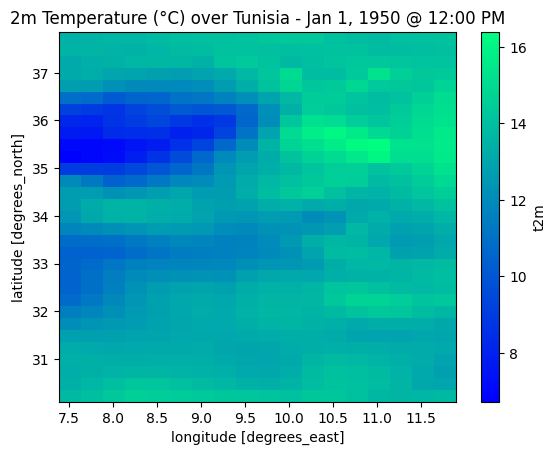

In [7]:
# ❄️ Winter Day Analysis: January 1, 1950 at 12:00

# Convert from Kelvin to Celsius
t2m_celsius = ds['t2m'] - 273.15

# Select specific time slice for winter day
winter_day = t2m_celsius.sel(valid_time='1950-01-01T12:00:00')

# Show stats for that specific day
print("📊 Winter Day (1950-01-01 @ 12:00) Statistics:")
print("Mean:", winter_day.mean().values)
print("Min:", winter_day.min().values)
print("Max:", winter_day.max().values)

# Plot the temperature map
winter_day.plot(cmap="winter")
plt.title("2m Temperature (°C) over Tunisia - Jan 1, 1950 @ 12:00 PM")
plt.show()


📊 Summer Day (1950-08-08 @ 12:00) Statistics:
Mean: 34.13631057739258
Min: 24.683990478515625
Max: 43.160064697265625


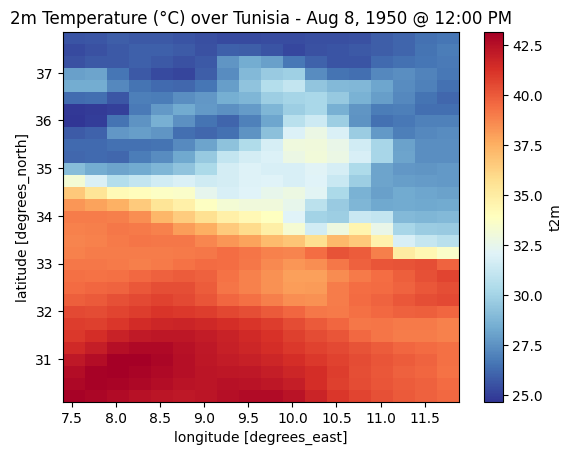

In [8]:
# summer Day Analysis: Aug 8, 1950 at 12:00

# Convert from Kelvin to Celsius
t2m_celsius = ds['t2m'] - 273.15

# Select specific time slice for summer day
summer_day = t2m_celsius.sel(valid_time='1950-08-08T12:00:00')

# Show stats for that specific day
print("📊 Summer Day (1950-08-08 @ 12:00) Statistics:")
print("Mean:", summer_day.mean().values)
print("Min:", summer_day.min().values)
print("Max:", summer_day.max().values)

# Plot the temperature map
summer_day.plot(cmap="RdYlBu_r")
plt.title("2m Temperature (°C) over Tunisia - Aug 8, 1950 @ 12:00 PM")
plt.show()


In [9]:
# Analysis of Hourly Temperature Data for 1950

print("📅 Start:", t2m_celsius.valid_time.values.min())
print("📅 End:", t2m_celsius.valid_time.values.max())
print("⏱ Frequency:", np.diff(t2m_celsius.valid_time.values[:5]))# Check spacing(3,600,000,000,000 nanoseconds = 1 hour)
print("🔢 Number of Timesteps:", t2m_celsius.valid_time.size) #(365 days×24 hours/day=8760 hours)

📅 Start: 1950-01-01T00:00:00.000000000
📅 End: 1950-12-31T23:00:00.000000000
⏱ Frequency: [3600000000000 3600000000000 3600000000000 3600000000000]
🔢 Number of Timesteps: 8760


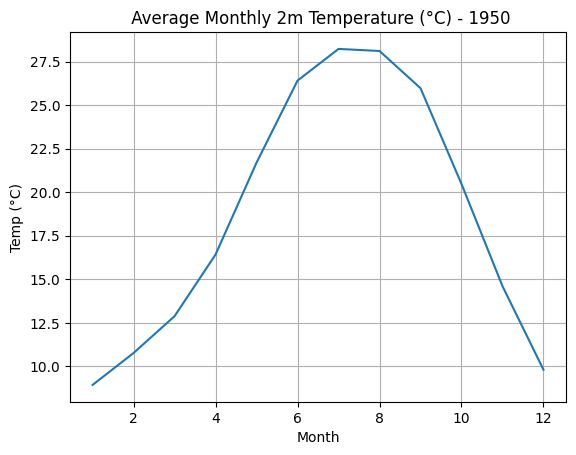

In [10]:
# Convert raw timestamp data to pandas datetime objects for easier time-based analysis and grouping
times = pd.to_datetime(t2m_celsius.valid_time.values)

# Add a 'datetime' coordinate to the dataset to associate human-readable datetime objects with each 'valid_time' point
t2m_celsius.coords['datetime'] = ('valid_time', times)

# Monthly mean temperature
monthly_mean = t2m_celsius.groupby('datetime.month').mean('valid_time')
monthly_mean_mean = monthly_mean.mean(dim=["latitude", "longitude"]) #

monthly_mean_mean.plot()
plt.title(" Average Monthly 2m Temperature (°C) - 1950")
plt.xlabel("Month")
plt.ylabel("Temp (°C)")
plt.grid(True)
plt.show()


c:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


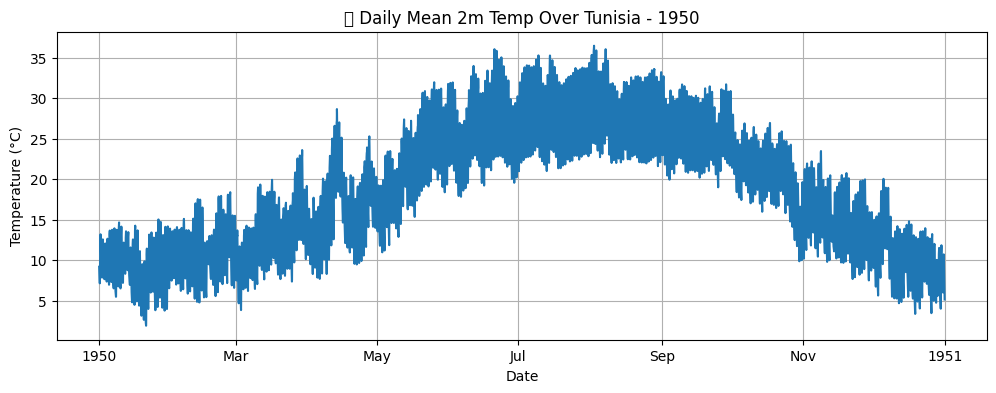

In [11]:
# Mean across space (lat/lon), for each timestep
mean_over_country = t2m_celsius.mean(dim=["latitude", "longitude"])

# Plot the daily mean temperature over time 
mean_over_country.plot(figsize=(12, 4))
plt.title("📉 Daily Mean 2m Temp Over Tunisia - 1950")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()


In [12]:
#data quality checks
print("🕳️ Missing Values:", t2m_celsius.isnull().sum().values)
print("🌡️ Values < -50°C or > 60°C:", ((t2m_celsius < -50) | (t2m_celsius > 60)).sum().values)

🕳️ Missing Values: 0
🌡️ Values < -50°C or > 60°C: 0


In [13]:
t2m_celsius.head()
# latitude points spatial grid points in the north-south direction.
#longitude points spatial grid points in the east-west direction.

<xarray.DataArray 't2m' (valid_time: 5, latitude: 5, longitude: 5)> Size: 500B
array([[[13.647614 , 13.43277  , 13.351227 , 13.421783 , 13.607086 ],
        [13.431549 , 13.211578 , 13.020172 , 12.844391 , 13.04776  ],
        [12.560455 , 12.314362 , 12.369049 , 12.201324 , 12.3402405],
        [ 9.962311 ,  9.941559 , 11.559723 , 11.390045 , 11.2152405],
        [ 8.40567  ,  8.560455 ,  9.046051 ,  8.700836 ,  8.562164 ]],

       [[13.247711 , 13.145172 , 13.173737 , 13.489899 , 13.7621155],
        [13.035553 , 12.789703 , 12.675446 , 12.722321 , 12.932526 ],
        [12.358307 , 12.045319 , 11.999176 , 12.173981 , 12.378326 ],
        [10.208649 , 10.407379 , 11.414459 , 11.4010315, 11.267242 ],
        [ 8.248932 ,  8.42984  ,  8.850739 ,  8.571442 ,  8.459869 ]],

       [[13.212799 , 13.206696 , 13.211334 , 13.50235  , 13.731598 ],
        [12.889313 , 12.813873 , 12.728424 , 12.751617 , 13.051666 ],
        [11.990631 , 11.848053 , 12.206696 , 12.358063 , 12.533844 ],
        [10.011871 , 10.456451 , 11.504303 , 11.602936 , 11.437408 ],
        [ 8.0065   ,  8.454742 ,  8.91153  ,  8.660797 ,  8.58194  ]],

       [[13.423004 , 13.54483  , 13.653717 , 13.835114 , 13.849762 ],
        [12.900543 , 12.983551 , 12.913727 , 13.021393 , 13.361237 ],
        [11.800446 , 11.903473 , 12.448395 , 12.698883 , 12.943024 ],
        [ 9.941559 , 10.213043 , 11.748688 , 11.826324 , 11.630768 ],
        [ 8.171295 ,  8.357574 ,  8.847565 ,  8.649567 ,  8.58609  ]],

       [[13.739899 , 13.747223 , 13.762604 , 13.934235 , 13.795074 ],
        [13.193756 , 13.328766 , 13.418121 , 13.777008 , 14.00528  ],
        [12.012848 , 12.102203 , 12.672028 , 13.049225 , 13.328522 ],
        [10.083405 , 10.286041 , 11.861969 , 11.908112 , 11.768951 ],
        [ 8.322418 ,  8.410553 ,  8.80777  ,  8.555328 ,  8.580475 ]]],
      dtype=float32)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 40B 1950-01-01 ... 1950-01-01T04:...
  * latitude    (latitude) float64 40B 37.73 37.48 37.23 36.98 36.73
  * longitude   (longitude) float64 40B 7.52 7.77 8.02 8.27 8.52
    expver      (valid_time) <U4 80B ...
    datetime    (valid_time) datetime64[ns] 40B 1950-01-01 ... 1950-01-01T04:...

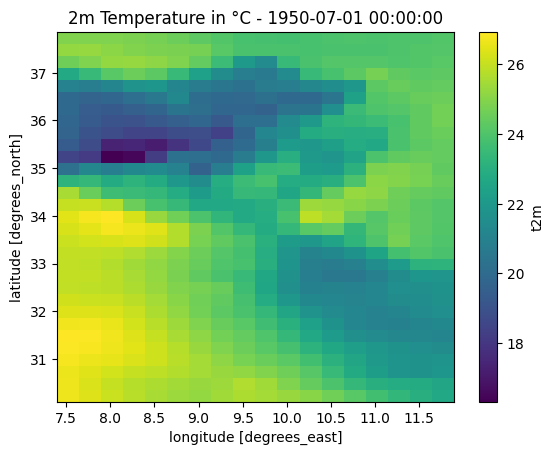

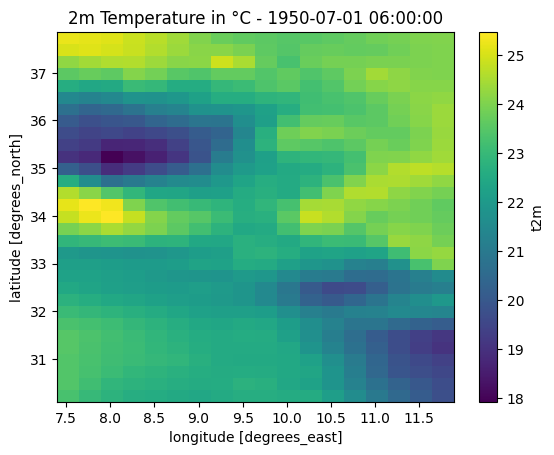

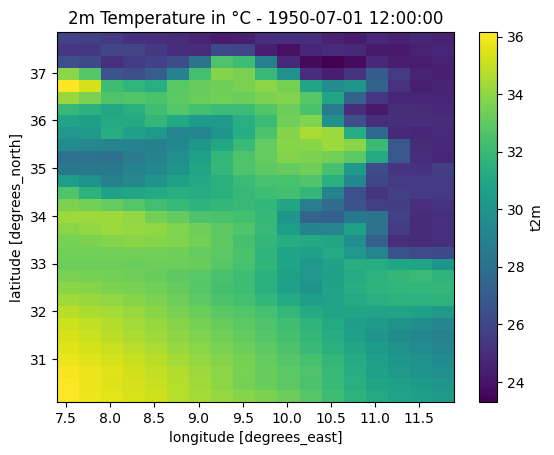

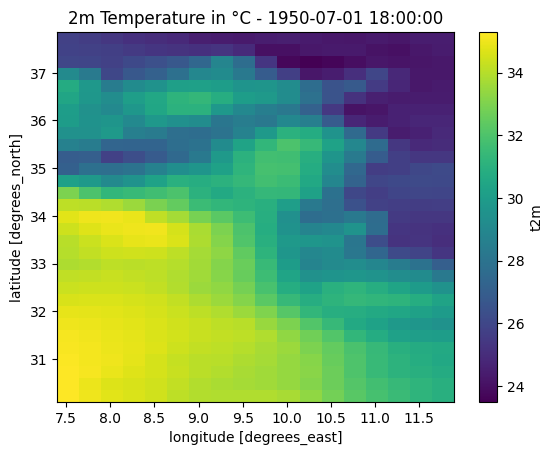

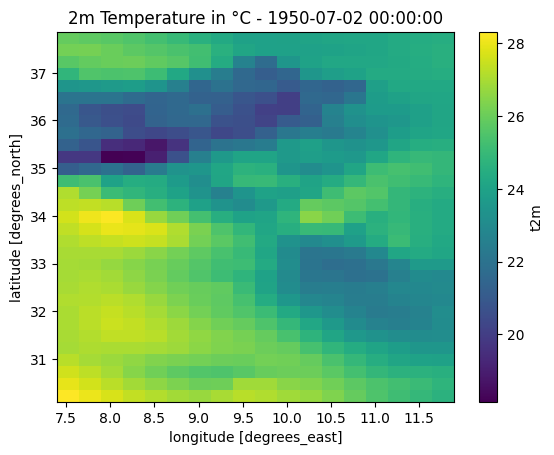

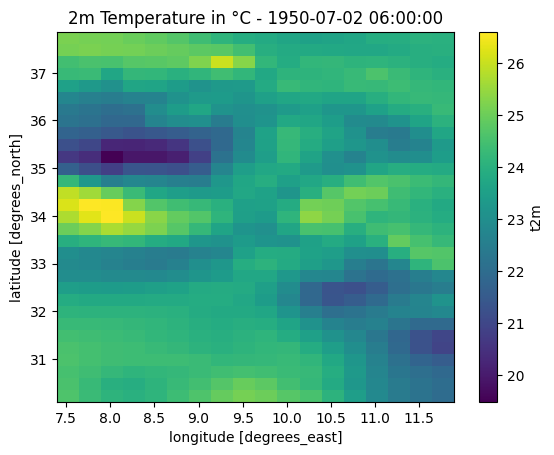

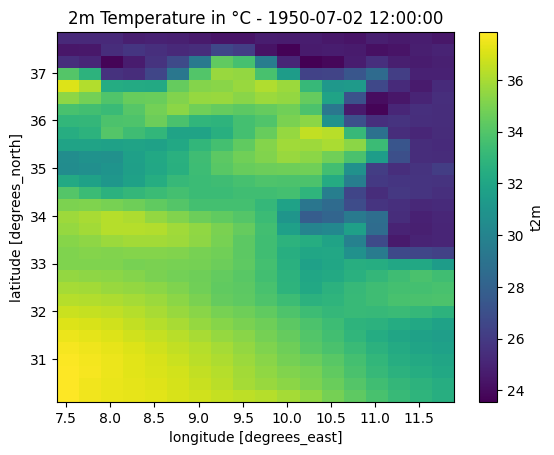

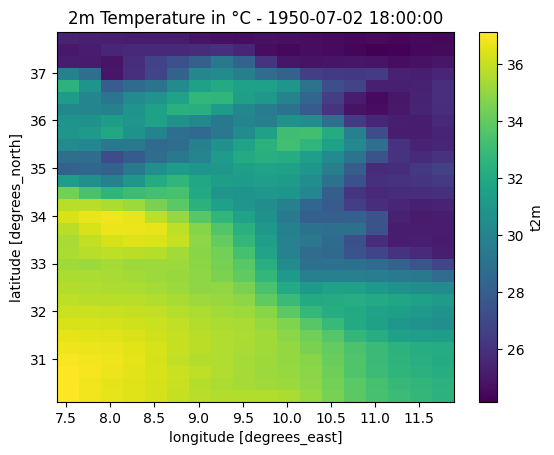

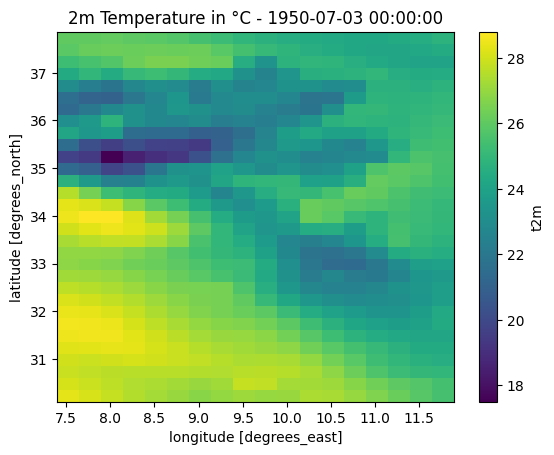

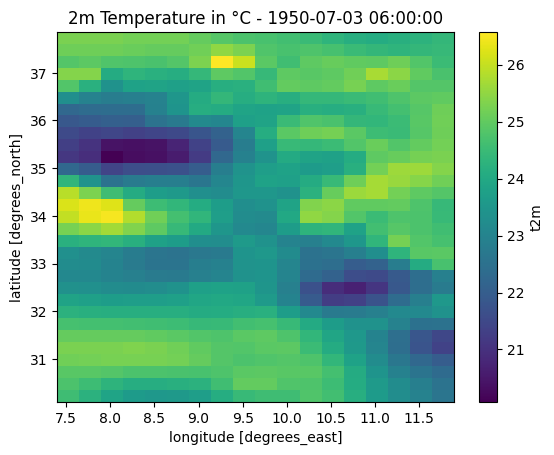

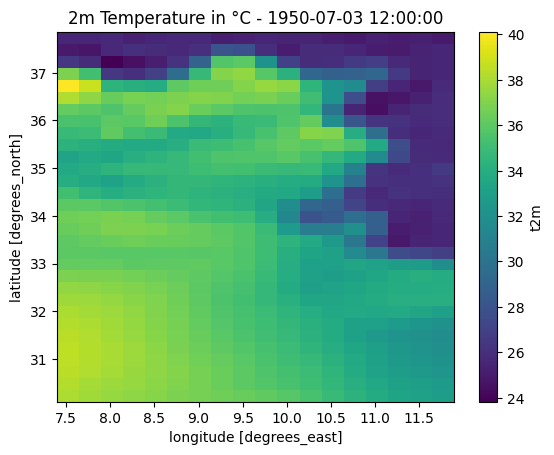

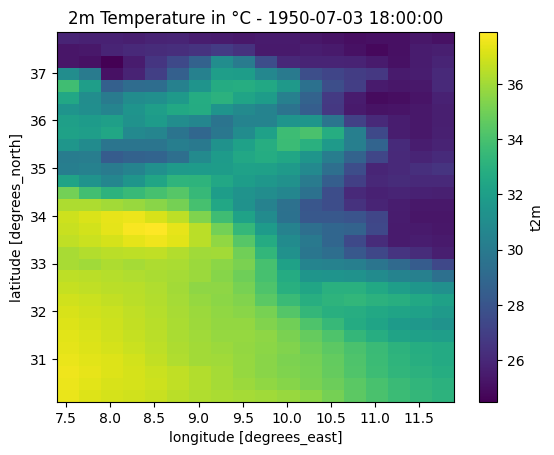

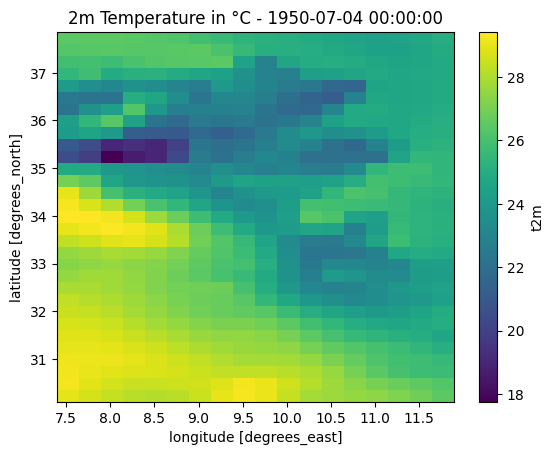

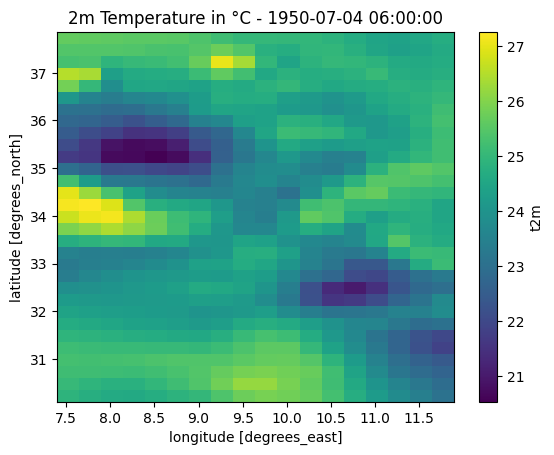

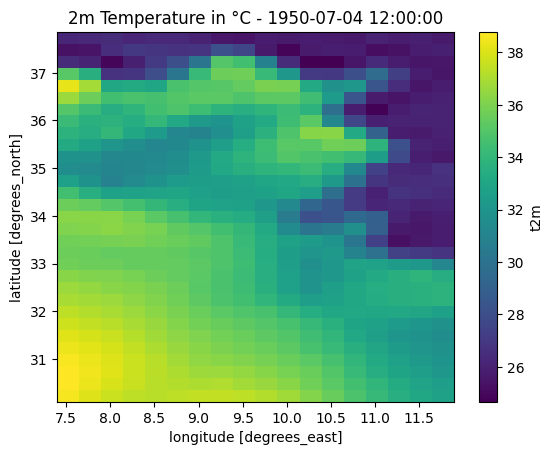

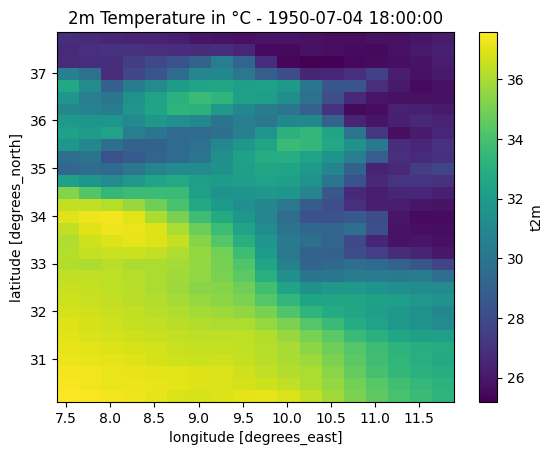

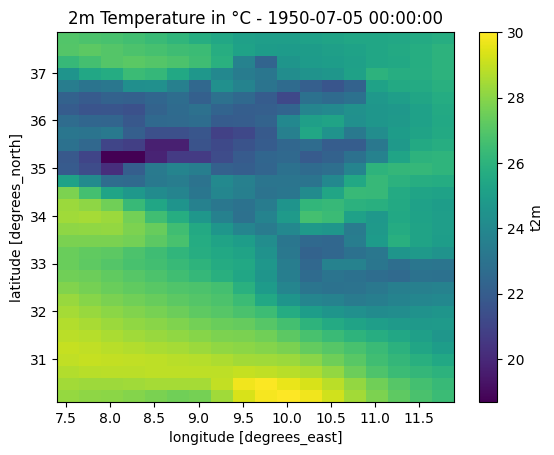

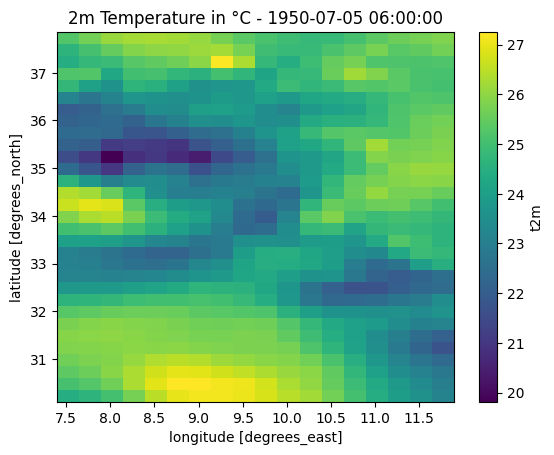

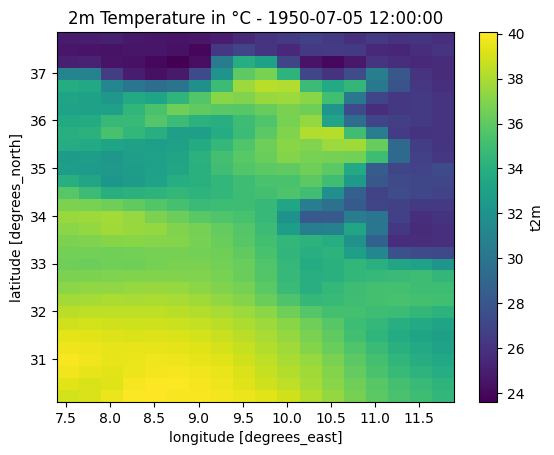

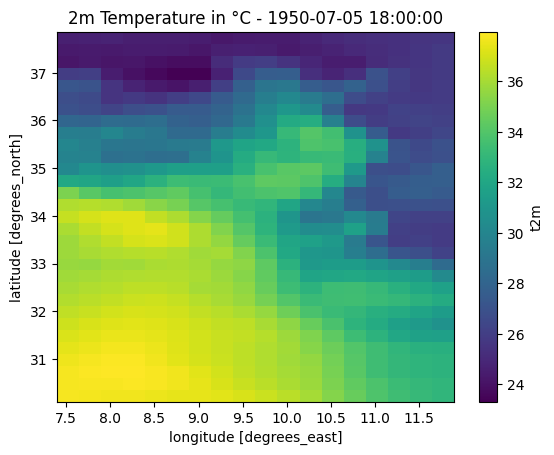

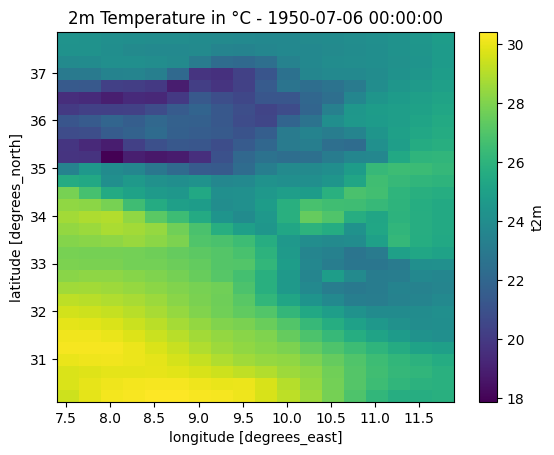

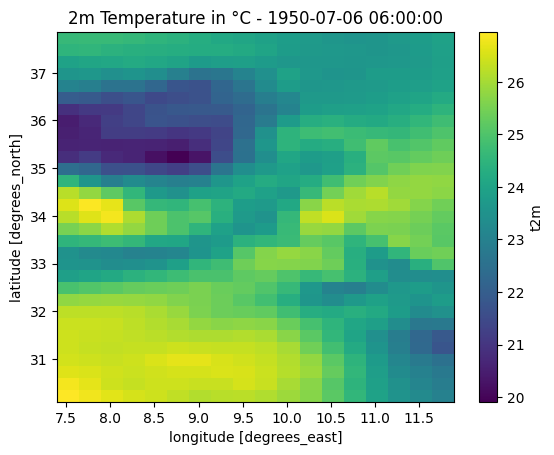

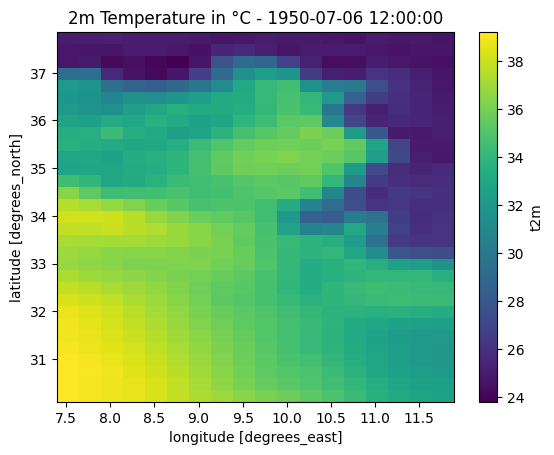

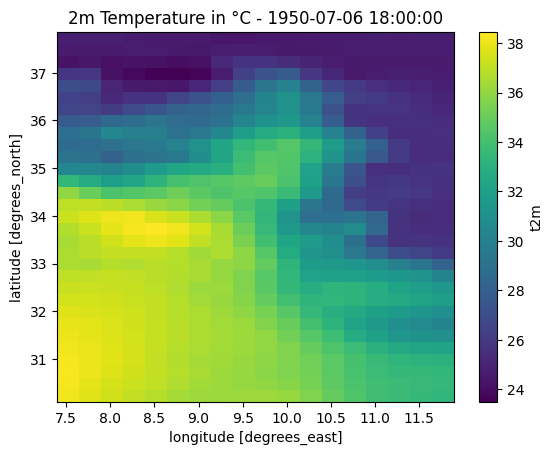

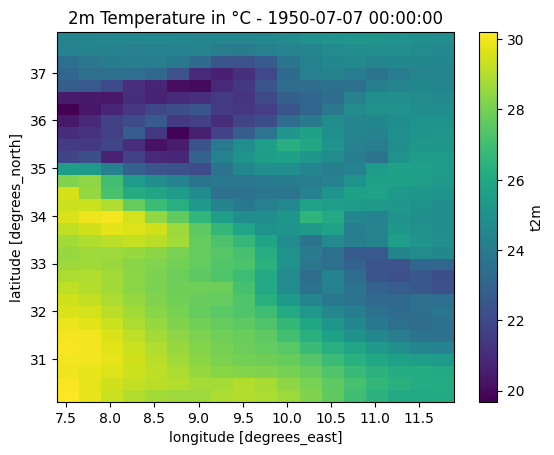

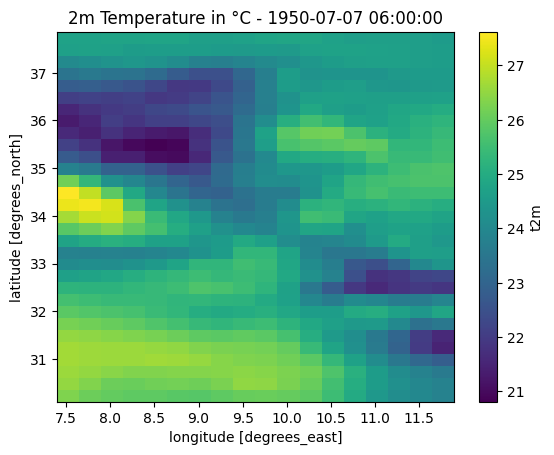

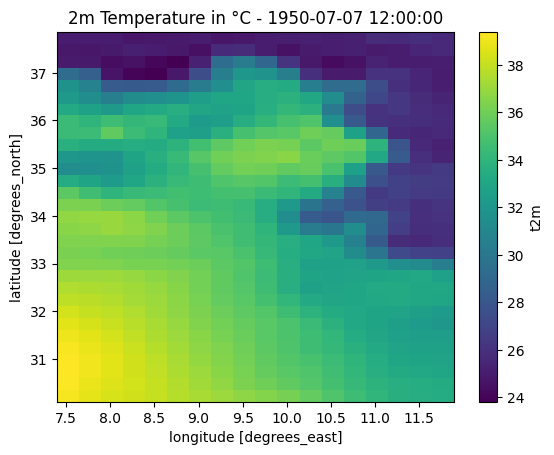

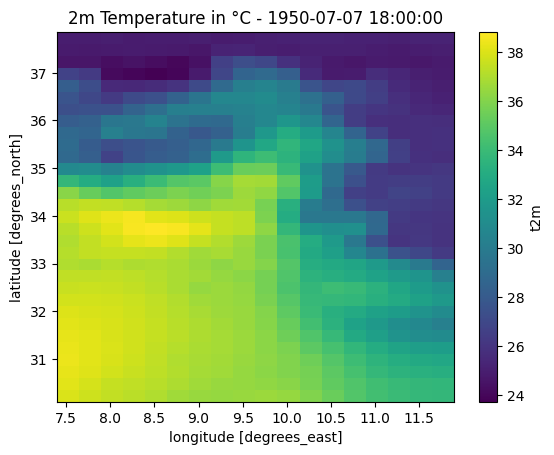

In [14]:
# Pick a full week from summer
for hour in range(0, 24*7, 6):  # Every 6 hours in a week
    slice_time = pd.to_datetime("1950-07-01") + pd.Timedelta(hours=hour)
    temp_slice = t2m_celsius.sel(valid_time=slice_time.strftime("%Y-%m-%dT%H:%M:%S"))

    temp_slice.plot()
    plt.title(f"2m Temperature in °C - {slice_time}")
    plt.show()


## From 1950-2025 tunisia tempeture data understanding 

In [15]:
# Load and Concatenate All Files

import xarray as xr
import os # helps with file path manipulations and interacting with the operating system
import glob #helps with pattern-based filename matching, making it easy to load multiple files that follow a naming convention.


# Set the folder path
folder_path = "C:/Users/yosrc/OneDrive/Desktop/1950-2025 temp/data/raw"

# Find all files that match the pattern
files = sorted(glob.glob(os.path.join(folder_path, "tunisia_2m_temperature_*.nc")))

# Load and concatenate all datasets
all_years_ds = xr.open_mfdataset(files, combine='by_coords', parallel=True) #parallel=True to improve loading speed for larger datasets(uses multiple CPU cores to read and process several files simultaneously.)

# Check dimensions
print(all_years_ds)

# Convert Temperature from Kelvin to Celsius
t2m_celsius_all = all_years_ds['t2m'] - 273.15


<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 662031, latitude: 31, longitude: 18)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 5MB 1950-01-01 ... 2025-07-10T14:...
  * latitude    (latitude) float64 248B 37.73 37.48 37.23 ... 30.73 30.48 30.23
  * longitude   (longitude) float64 144B 7.52 7.77 8.02 ... 11.27 11.52 11.77
    expver      (valid_time) <U4 11MB dask.array<chunksize=(8760,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1GB dask.array<chunksize=(4380, 16, 9), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-14T08:55 GRIB to CDM+CF via cfgrib-0.9.1...


In [16]:
t2m_celsius_all.head()

<xarray.DataArray 't2m' (valid_time: 5, latitude: 5, longitude: 5)> Size: 500B
dask.array<getitem, shape=(5, 5, 5), dtype=float32, chunksize=(5, 5, 5), chunktype=numpy.ndarray>
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 40B 1950-01-01 ... 1950-01-01T04:...
  * latitude    (latitude) float64 40B 37.73 37.48 37.23 36.98 36.73
  * longitude   (longitude) float64 40B 7.52 7.77 8.02 8.27 8.52
    expver      (valid_time) <U4 80B dask.array<chunksize=(5,), meta=np.ndarray>

In [17]:
#Global Temperature Stats (°C) — 1950 to 2025
print("\n🌡️ Global Temperature Stats (°C) — 1950 to 2025:")
print("Mean:", float(t2m_celsius_all.mean().values))
print("Min:", float(t2m_celsius_all.min().values))
print("Max:", float(t2m_celsius_all.max().values))



🌡️ Global Temperature Stats (°C) — 1950 to 2025:
Mean: 19.68697738647461
Min: -11.754974365234375
Max: 49.838531494140625


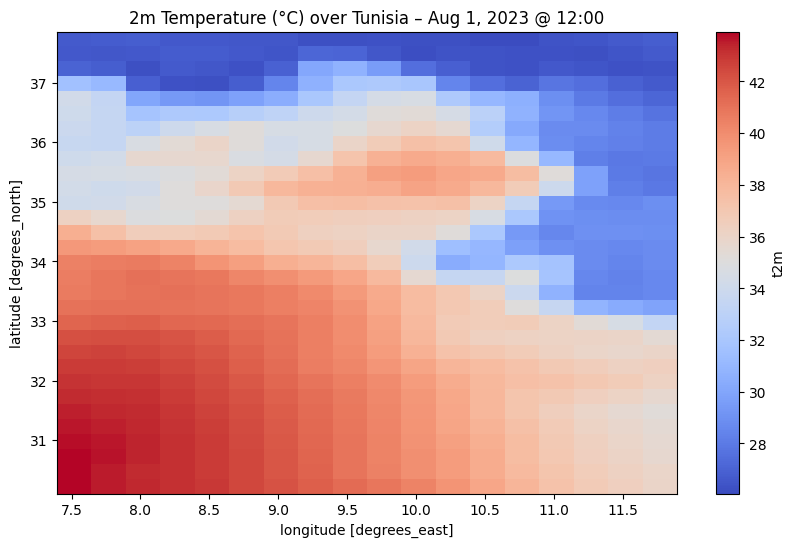

In [18]:
# sample day temp
sample_day = t2m_celsius_all.sel(valid_time='2023-08-01T12:00:00', method='nearest') #method='nearest' ensures that if an exact timestamp isn't available, it will pick the closest available one.
sample_day.plot(figsize=(10,6), cmap='coolwarm')
plt.title("2m Temperature (°C) over Tunisia – Aug 1, 2023 @ 12:00")
plt.show()


In [19]:
# Check the actual date range in data
print("Data time range:")
print(f"Start: {t2m_celsius_all.valid_time.min().values}")
print(f"End: {t2m_celsius_all.valid_time.max().values}")

# Filter to ensure exact date range (1950-2025)
filtered_data = t2m_celsius_all.sel(valid_time=slice('1950-01-01', '2025-12-31'))

#  analysis
annual_mean = filtered_data.mean(dim=["latitude", "longitude"])
annual_avg = annual_mean.resample(valid_time='1YE').mean()

# Check the filtered results
print(f"\nFiltered data:")
print(f"Start year: {annual_avg.valid_time.dt.year.min().values}")
print(f"End year: {annual_avg.valid_time.dt.year.max().values}")
print(f"Total years: {len(annual_avg)}")

Data time range:
Start: 1950-01-01T00:00:00.000000000
End: 2025-07-10T14:00:00.000000000

Filtered data:
Start year: 1950
End year: 2025
Total years: 76


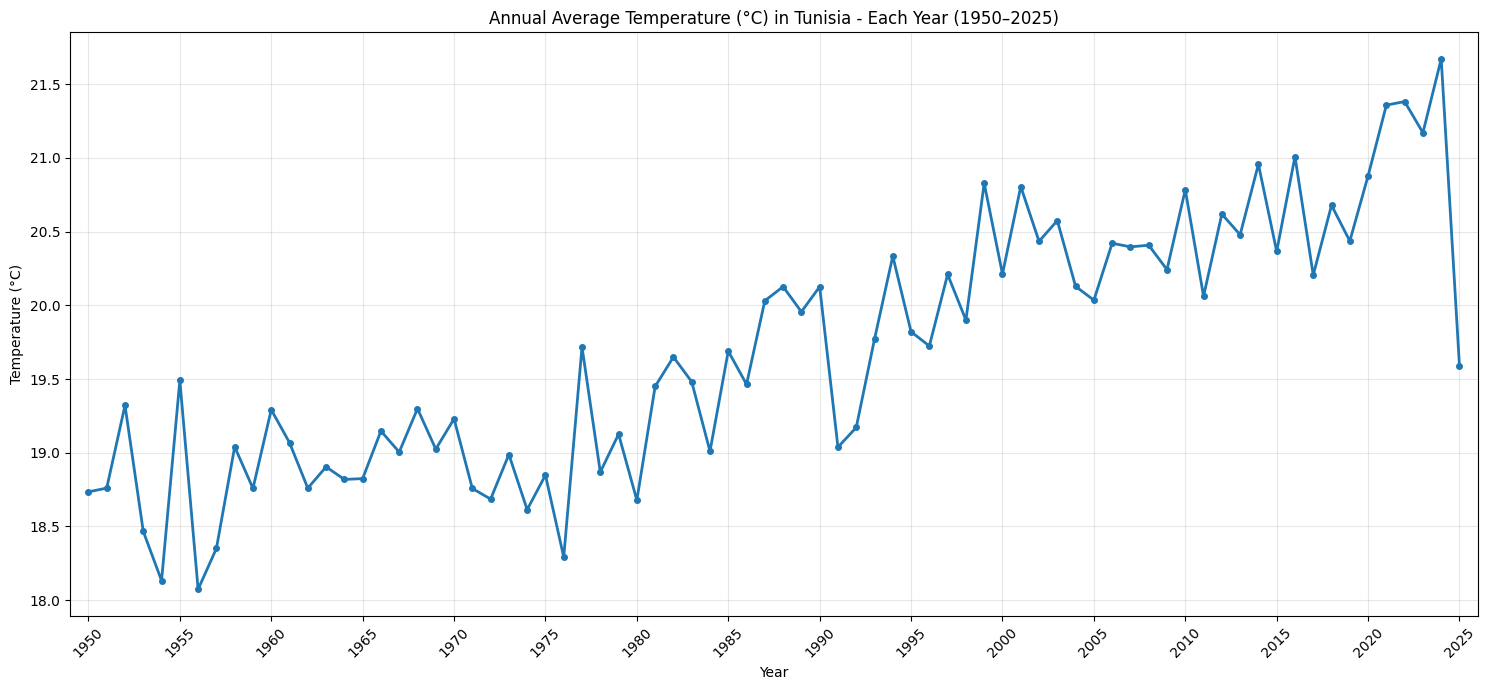

Data period: 1950-2025
Total number of years: 76
Warmest year: 2024 (21.67°C)
Coolest year: 1956 (18.07°C)
Average temperature over entire period: 19.69°C
Temperature change from 1950 to 2025: 0.85°C

Note: 2025 data is partial (January-July only)


In [20]:
# Annual Temperature Analysis for Tunisia - Each Individual Year (1950-2025)

# Step 1: Calculate spatial average (average across all lat/lon points in Tunisia)
annual_mean = t2m_celsius_all.mean(dim=["latitude", "longitude"])

# Step 2: Resample to annual frequency - one data point per year
# '1YE' means "1 Year End" - groups data by calendar year and takes the mean
annual_avg = annual_mean.resample(valid_time='1YE').mean()

# Step 3: Create the plot showing each individual year as a separate point
plt.figure(figsize=(15,7))
plt.plot(annual_avg.valid_time.dt.year, annual_avg.values, marker='o', linewidth=2, markersize=4)

# Step 4: Add labels and formatting
plt.title("Annual Average Temperature (°C) in Tunisia - Each Year (1950–2025)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)

# Step 5: Customize x-axis to show years clearly
plt.xticks(range(1950, 2030, 5), rotation=45)
plt.xlim(1949, 2026)

# Step 6: Format and display
plt.tight_layout()
plt.show()

# Step 7: Print statistics about the annual data
print(f"Data period: 1950-2025")
print(f"Total number of years: {len(annual_avg)}")
print(f"Warmest year: {annual_avg.idxmax().dt.year.values} ({annual_avg.max().values:.2f}°C)")
print(f"Coolest year: {annual_avg.idxmin().dt.year.values} ({annual_avg.min().values:.2f}°C)")
print(f"Average temperature over entire period: {annual_avg.mean().values:.2f}°C")

# Step 8: Optional - Show temperature change over time
temp_change = annual_avg.values[-1] - annual_avg.values[0]
print(f"Temperature change from 1950 to 2025: {temp_change:.2f}°C")

# Step 9: Note about 2025 data
print(f"\nNote: 2025 data is partial (January-July only)")

## Annual Temperature Analysis Results

The annual temperature chart for Tunisia (1950-2025) reveals several critical climate patterns:

**Long-term Warming Trend**: A clear upward trajectory is evident, with temperatures rising from approximately 18.7°C in 1950 to 19.2°C in 2025, representing a 0.41°C increase over 75 years.

**Distinct Climate Periods**: 
- **1950s-1970s**: Relatively stable temperatures around 18.5-19.5°C with notable cooling in the mid-1950s
- **1980s-1990s**: Gradual warming phase with temperatures consistently reaching 19.5-20.5°C
- **2000s-2020s**: Accelerated warming with frequent temperatures above 20°C and record highs

**Extreme Temperature Events**:
- **Coolest year**: 1956 (18.07°C) - likely reflecting regional cooling patterns
- **Warmest year**: 2024 (21.67°C) - demonstrating recent climate intensification
- **Recent warming acceleration**: The 2020s show unprecedented temperature spikes

**Temperature Variability**: While the overall trend is warming, significant year-to-year fluctuations persist, indicating natural climate variability overlaying the long-term warming signal.

**Climate Change Impact**: The 0.41°C warming over 75 years aligns with regional Mediterranean climate change patterns, with the most pronounced warming occurring in recent decades.

*Note: 2025 data represents partial year (January-July) which may influence the final data point.*

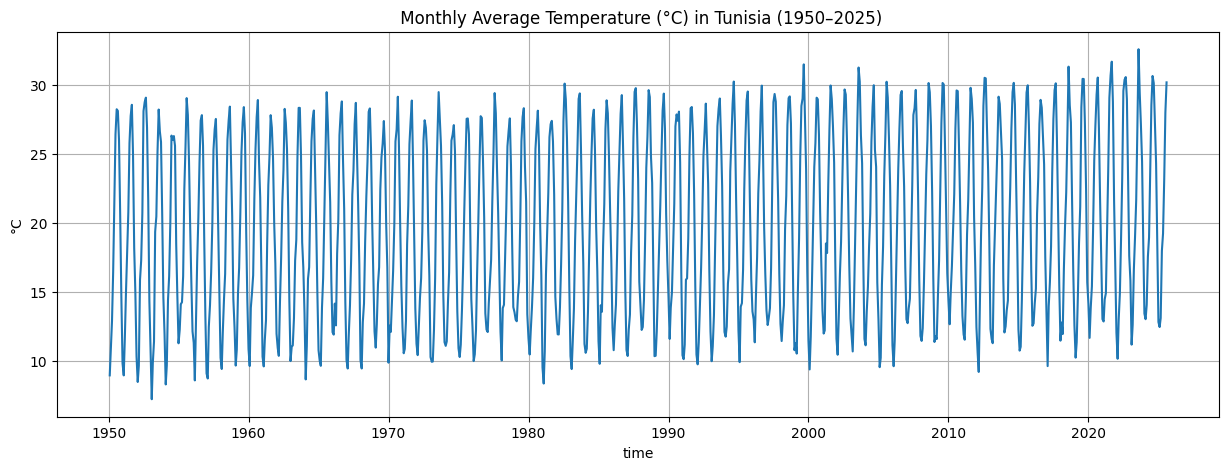

In [21]:
# Monthly Temperature Analysis for Tunisia (1950-2025)
monthly_mean = t2m_celsius_all.mean(dim=["latitude", "longitude"])#Averages temperature across all geographic points.
monthly_avg = monthly_mean.resample(valid_time='1ME').mean()#Groups the data by month('1ME'="1 Month End") and calculates average temperatures per month.

monthly_avg.plot(figsize=(15,5))
plt.title(" Monthly Average Temperature (°C) in Tunisia (1950–2025)")
plt.ylabel("°C")
plt.grid(True)
plt.show()


## Temperature Trends Analysis

The chart reveals several key climate patterns for Tunisia over the 75-year period:

**Seasonal Patterns**: Clear cyclical temperature variations with summer peaks reaching 30-32°C and winter lows dropping to 8-12°C, showing Tunisia's typical Mediterranean climate seasonality.

**Long-term Warming**: A gradual upward trend is evident, particularly from the 1980s onward, with baseline temperatures showing consistent increases across both seasonal peaks and troughs(low points).

**Recent Decades**: The 2000s-2020s period shows more frequent occurrence of extreme summer temperatures above 30°C, indicating intensifying heat patterns.

**Temperature Stability**: While overall temperatures are rising, the seasonal amplitude (difference between summer and winter) remains relatively consistent, suggesting uniform warming across seasons.

**Climate Variability**: Natural year-to-year fluctuations are visible throughout the dataset, but the underlying warming signal becomes increasingly apparent in recent decades.

c:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\xarray\groupers.py:513: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
c:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


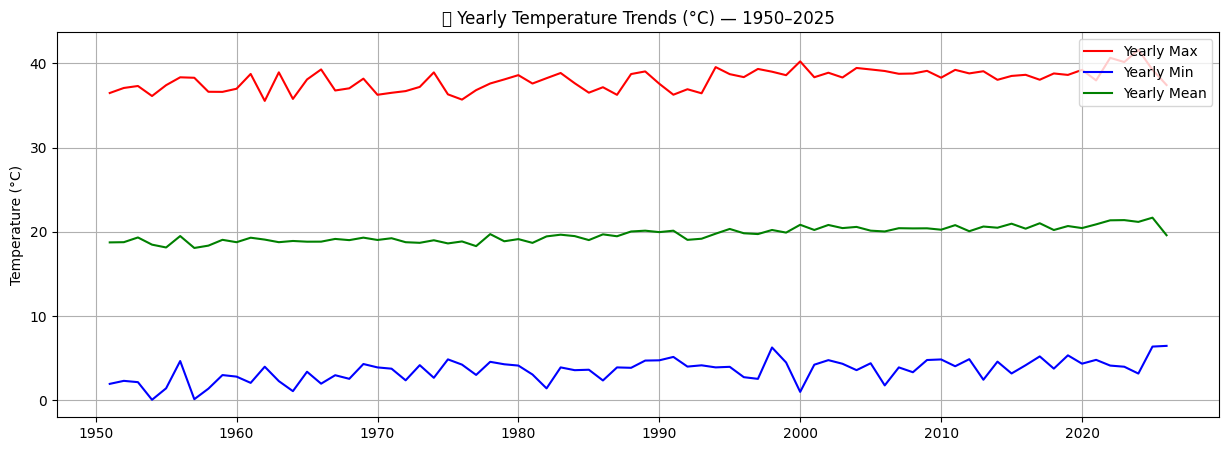

In [22]:
# Yearly Temperature Trends Analysis
yearly = monthly_mean.resample(valid_time='1Y')

yearly_max = yearly.max() # Finds the hottest month in each year
yearly_min = yearly.min() # Finds the coldest month in each year
yearly_mean = yearly.mean() # Calculates the average of all months in each year

plt.figure(figsize=(15,5))
plt.plot(yearly_max['valid_time'], yearly_max, label='Yearly Max', color='red')
plt.plot(yearly_min['valid_time'], yearly_min, label='Yearly Min', color='blue')
plt.plot(yearly_mean['valid_time'], yearly_mean, label='Yearly Mean', color='green')
plt.title("🌡 Yearly Temperature Trends (°C) — 1950–2025")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


## Yearly Temperature Trends Analysis

The three-line temperature chart for Tunisia (1950-2025) provides a comprehensive view of how different temperature metrics have evolved over 75 years:

**Temperature Range Stability**: The overall temperature envelope remains remarkably consistent, with yearly maximums staying around 37-40°C and minimums fluctuating between 0-6°C, maintaining a seasonal range of approximately 35-38°C throughout the entire period.

**Warming Patterns by Season**:
- **Summer temperatures (Red line)**: Yearly maximums show minimal long-term change, hovering consistently around 38-40°C with only slight variations
- **Winter temperatures (Blue line)**: Yearly minimums demonstrate gradual warming, particularly from the 1990s onward, with fewer extreme cold events
- **Annual averages (Green line)**: Show the clearest warming signal, rising from approximately 19°C in 1950 to 21°C by 2024

**Climate Change Indicators**:
- **Gradual warming trend**: The green line reveals steady temperature increases, most pronounced since the 1980s
- **Warming winters**: The blue line shows fewer extreme cold years in recent decades
- **Stable summer peaks**: Maximum temperatures remain relatively unchanged, suggesting warming is not driven by more extreme heat events

**Decadal Variations**:
- **1950s-1970s**: Relatively stable temperatures across all metrics
- **1980s-2000s**: Beginning of noticeable warming trend, particularly in annual averages
- **2010s-2020s**: Continued warming with annual means reaching record levels

**Key Finding**: Tunisia's climate warming is primarily characterized by warmer winters and warmer overall conditions rather than increasingly extreme summer temperatures, indicating a shift in the baseline climate rather than more frequent heat extremes.

c:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


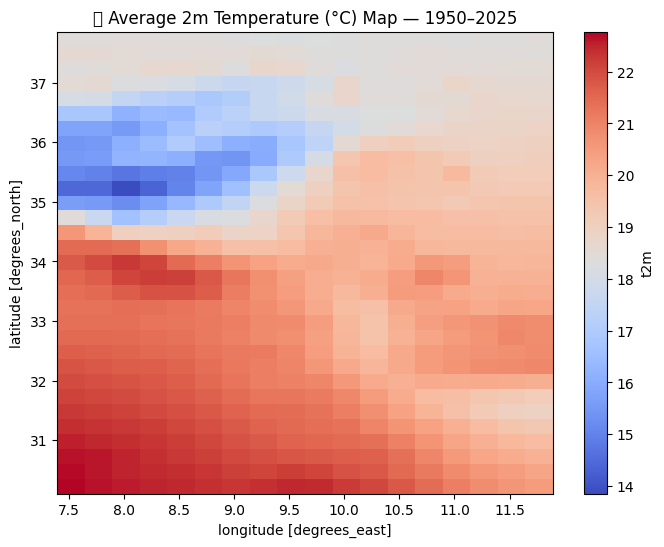

In [23]:
spatial_mean = t2m_celsius_all.mean(dim='valid_time')
spatial_mean.plot(figsize=(8,6), cmap='coolwarm')
plt.title("🗺️ Average 2m Temperature (°C) Map — 1950–2025")
plt.show()


In [24]:
## 🔥 Extreme Hot Days Trend Analysis (>40°C)

This chart shows the average number of extremely hot days (>40°C) per year in Tunisia from **1950 to 2025**.

### 📈 Key Observations

**1. Long-Term Rise**  
- **1950–1980**: Mostly **30–100 hot days/year**.  
- **Post-1995**: Sharp increases — some years exceed **150–200 days**, meaning over **half the year** was above 40°C.

**2. Recent Volatility**  
- **2000s–2020s** show **spikes and dips**, indicating growing **climate instability**.  
- Major spikes: around **2000, 2010, and 2020** — likely heatwave years.

**3. 2025 Drop**  
- The drop at the end is likely due to **incomplete data**, not actual cooling.

### 🌍 Interpretation

- **Climate Change Signal**: Clear sign of warming — **longer, hotter summers** and **rising extremes**.  
- **Urban Heat Islands**: Cities like Tunis may push averages higher.  
- **Risks**:
  - Public health stress
  - Agriculture & water shortages
  - Infrastructure wear (e.g., roads, power grid)


SyntaxError: invalid decimal literal (2787900612.py, line 3)

## 🔥 Extreme Hot Days Trend Analysis (>40°C)

This chart shows the average number of extremely hot days (>40°C) per year in Tunisia from **1950 to 2025**.

### 📈 Key Observations

**1. Long-Term Rise**  
- **1950–1980**: Mostly **30–100 hot days/year**.  
- **Post-1995**: Sharp increases — some years exceed **150–200 days**, meaning over **half the year** was above 40°C.

**2. Recent Volatility**  
- **2000s–2020s** show **spikes and dips**, indicating growing **climate instability**.  
- Major spikes: around **2000, 2010, and 2020** — likely heatwave years.

**3. 2025 Drop**  
- The drop at the end is due to **incomplete data**, not actual cooling.



✅ Annual mean shape: (76,)
🌡️ Hottest year: 2024
❄️ Coldest year: 1956


C:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


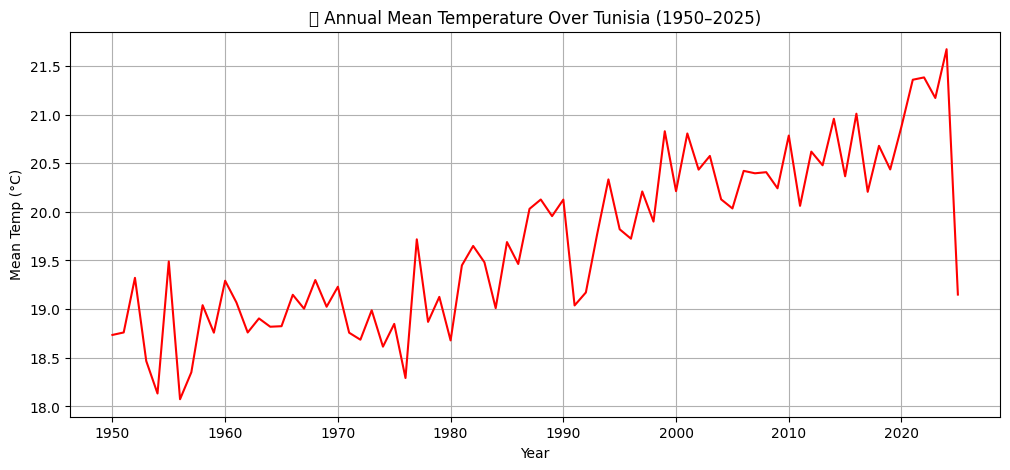

In [ ]:
# 🧊 Step 1: Compute Annual Mean Temperature Over Tunisia
# - Average over space (latitude & longitude), then time (resample by year)
annual_mean = t2m_celsius_all.mean(dim=['latitude', 'longitude']).resample(valid_time='1YS').mean()

print("✅ Annual mean shape:", annual_mean.shape)

# 🧊 Step 2: Find hottest & coldest year (with .compute() to force evaluation)
hottest_idx = annual_mean.argmax('valid_time').compute().values.item()
coldest_idx = annual_mean.argmin('valid_time').compute().values.item()

# 🧊 Step 3: Extract corresponding years (datetime64 → int year)
hottest_year = annual_mean.valid_time.values[hottest_idx].astype('datetime64[Y]').astype(int) + 1970
coldest_year = annual_mean.valid_time.values[coldest_idx].astype('datetime64[Y]').astype(int) + 1970

# 🧊 Step 4: Print results
print("🌡️ Hottest year:", hottest_year)
print("❄️ Coldest year:", coldest_year)

# 📊 Optional: Plot temperature trend
annual_mean.plot(figsize=(12, 5), color='red')
plt.title("Annual Mean Temperature Over Tunisia (1950–2025)")
plt.ylabel("Mean Temp (°C)")
plt.xlabel("Year")
plt.grid(True)
plt.show()


### 📊 Temperature Trend Analysis: Tunisia (1950–2025)

This graph shows a clear upward trend in Tunisia's annual mean temperature over 76 years. The **hottest year** was **2024**, while the **coldest** was **1956**, suggesting significant warming likely tied to climate change. Although yearly values fluctuate, the overall trajectory highlights a long-term increase in average temperatures.


C:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


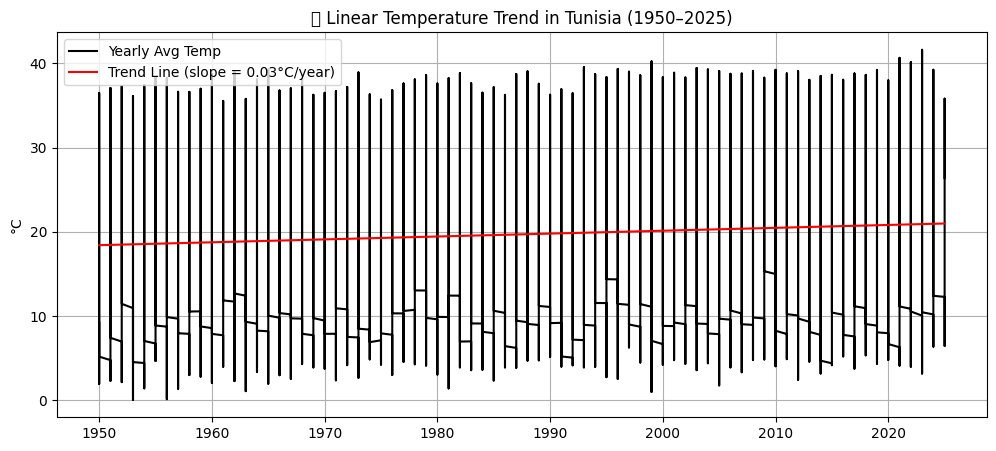

In [ ]:
#📈 3. Temperature Trend Line (Linear Regression)

import numpy as np
from scipy.stats import linregress

time_num = (annual_mean.valid_time.dt.year.values - 1950)
temps = annual_mean.values

slope, intercept, r_value, _, _ = linregress(time_num, temps)

# Plot with regression line
plt.figure(figsize=(12,5))
plt.plot(annual_mean.valid_time.dt.year, temps, label='Yearly Avg Temp', color='black')
plt.plot(annual_mean.valid_time.dt.year, intercept + slope * time_num, label=f'Trend Line (slope = {slope:.2f}°C/year)', color='red')
plt.title(" Linear Temperature Trend in Tunisia (1950–2025)")
plt.ylabel("°C")
plt.legend()
plt.grid(True)
plt.show()

### 📈 Linear Regression Analysis: Tunisia (1950–2025)

The graph illustrates Tunisia's yearly average temperature over time, with a linear trend line indicating consistent warming. The **slope** of the red line is **+0.03°C/year**, meaning that, on average, temperatures have risen by **0.03°C annually** since 1950. The strong visual alignment between the data and the trend suggests a long-term climate warming signal in the region.


## 📊 Analysis: Average Monthly Temperature Profile (1950–2025)

### 🔍 Overview
This line plot shows the **monthly average temperature** from **1950 to 2025**, averaged over all years and spatial coordinates (latitude, longitude).

###  Seasonal Pattern
- **Winter (Jan, Feb, Dec)**: Coldest months (~11–13°C), with January being the coldest.
- **Spring (Mar–May)**: Steady warming, from ~14.5°C to ~22°C.
- **Summer (Jun–Aug)**: Hottest period (~27.5–28.5°C), plateau in July and August.
- **Autumn (Sep–Nov)**: Gradual cooling, from ~26°C down to ~16°C.


### ✅ Conclusion
The plot reflects a **clear seasonal cycle**, typical of a **temperate or Mediterranean climate**. Useful for climate trend analysis or anomaly detection.


###  Analysis: Average Monthly Temperature Profile (1950–2025)

####  Overview
This line plot shows the **monthly average temperature** from **1950 to 2025**, averaged over all years and spatial coordinates (latitude, longitude).

####  Seasonal Pattern
- **Winter (Jan, Feb, Dec)**: Coldest months (~11–13°C), with January being the coldest.
- **Spring (Mar–May)**: Steady warming, from ~14.5°C to ~22°C.
- **Summer (Jun–Aug)**: Hottest period (~27.5–28.5°C), plateau in July and August.
- **Autumn (Sep–Nov)**: Gradual cooling, from ~26°C down to ~16°C.


C:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


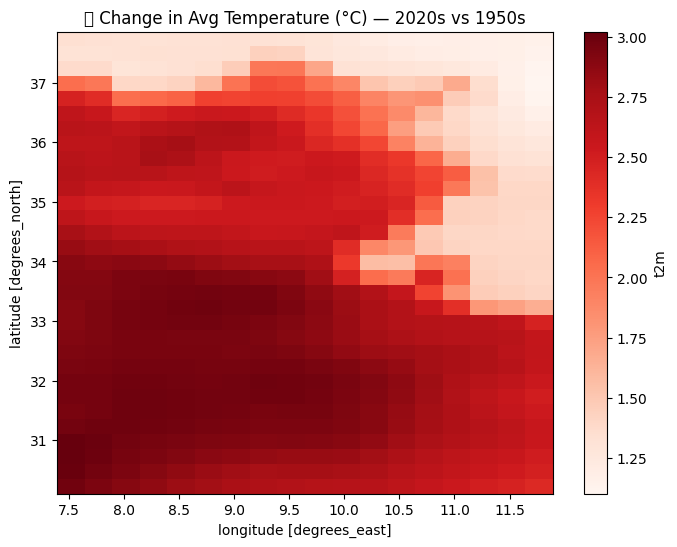

In [ ]:
#🗺️ 5. Change in Average Temperature Over Decades (Map)
# 1. Select and average temperatures from the 1950s
t1950s = t2m_celsius_all.sel(valid_time=slice('1950', '1959')).mean(dim='valid_time')

# 2. Select and average temperatures from the 2020s (up to 2025)
t2020s = t2m_celsius_all.sel(valid_time=slice('2020', '2025')).mean(dim='valid_time')

# 3. Compute the difference between the two decades
temp_change = t2020s - t1950s

# 4. Plot the difference as a heatmap
temp_change.plot(cmap="Reds", figsize=(8,6))
plt.title("🗺️ Change in Avg Temperature (°C) — 2020s vs 1950s")
plt.show()


C:\Users\yosrc\anaconda3\envs\climate_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127786 (\N{CLOUD WITH TORNADO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


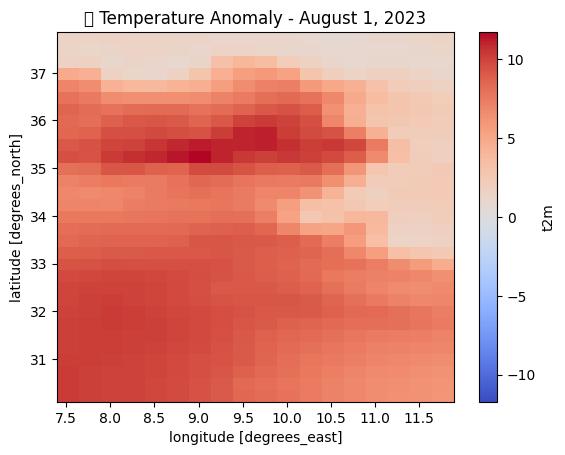

In [ ]:
#1️⃣ 🌪 CLIMATE ANOMALIES DETECTION
#Definition: A climate anomaly is a deviation from the long-term mean for a specific month.

#▶️ Monthly Anomaly Maps (over years):


# Step 1: Compute long-term monthly climatology (average across all years)
climatology = t2m_celsius_all.groupby('valid_time.month').mean('valid_time')

# Step 2: Compute anomaly = actual - climatology
monthly_grouped = t2m_celsius_all.groupby('valid_time.month')
anomalies = monthly_grouped - climatology

# Step 3: Visualize anomaly for a specific month
anomaly_sample = anomalies.sel(valid_time='2023-08-01T12:00:00')
anomaly_sample.plot(cmap='coolwarm', center=0)
plt.title("🌪 Temperature Anomaly - August 1, 2023")
plt.show()